In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Opg 1.1

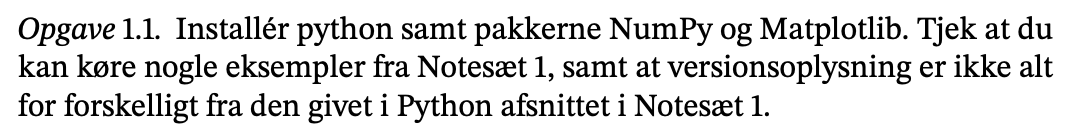

# Opg 1.2

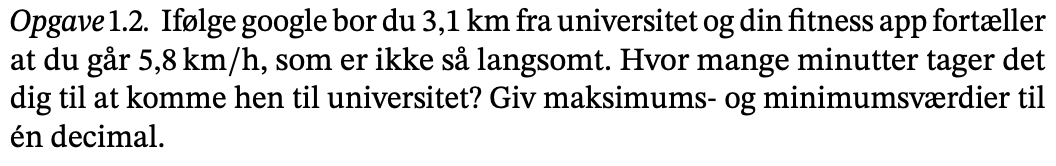

Beregning af præcis hvor mange minutter det tager:

$$v = 5.8 \frac{km}{h} = \frac{5.8}{60} \frac{km}{\text{min}}$$
$$s = 3.1 km$$

$$t_{lower} = \frac{3.05 km}{\frac{5.85}{60} \frac{km}{\text{min}}} = 31.282051282051285 \text{min}$$

$$t_{upper} = \frac{3.15 km}{\frac{5.75}{60} \frac{km}{\text{min}}} = 32.92173913043478 \text{min}$$

Dette tal repræsenterer alle tal i intervallet $[31.282051282051285 \text{min}, 32.92173913043478 \text{min}]$.

Se slut side 3 i Notesæt 1 for forklaring.

# Opg 1.3

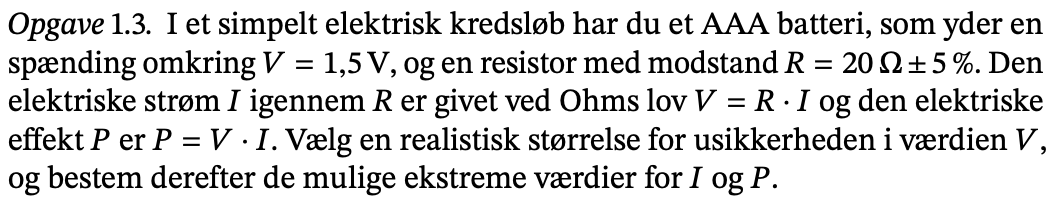

Først vælger jeg en realistisk størrelse for værdien af $V$, på samme måde som i forrige opgave.

$$V' \in [1.45 \text{V}, 1.55 \text{V}]$$

Derudover beregner jeg intervallet for resistancen:

$$R' \in [19 \Omega, 21 \Omega]$$

Jeg bruger nu følgende proposition til at bestemme ekstremværdierne for $I$ og $P$:

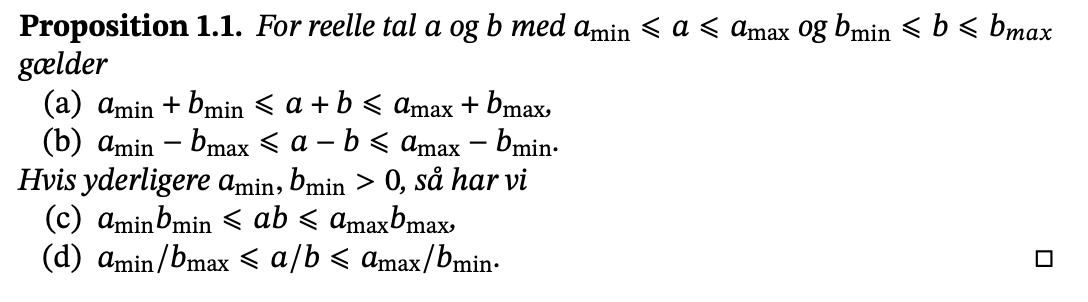

$I$:

Jeg bruger linje (d), da jeg skal bruge formlen: $$V = RI \Leftrightarrow I = \frac{V}{R}$$


$$I_{lower} = \frac{1.45 \text{V}}{21 \Omega} = \frac{1.45}{21} A$$

$$I_{upper} = \frac{1.55 \text{V}}{19 \Omega} = \frac{1.55}{19} A$$

Dermed må $I \in [\frac{1.45 }{21} A, \frac{1.55 }{19} A]$

$P$:

Jeg bruger linje (c), da jeg skal bruge formlen: $$P = V * I$$

$$P_{lower} = 1.45 \text{V} * \frac{1.45}{21} A = \frac{2.1025}{21} W$$

$$P_{upper} = 1.55 \text{V} * \frac{1.55}{19} A = \frac{2.4025}{19} W$$

# Opg 1.4

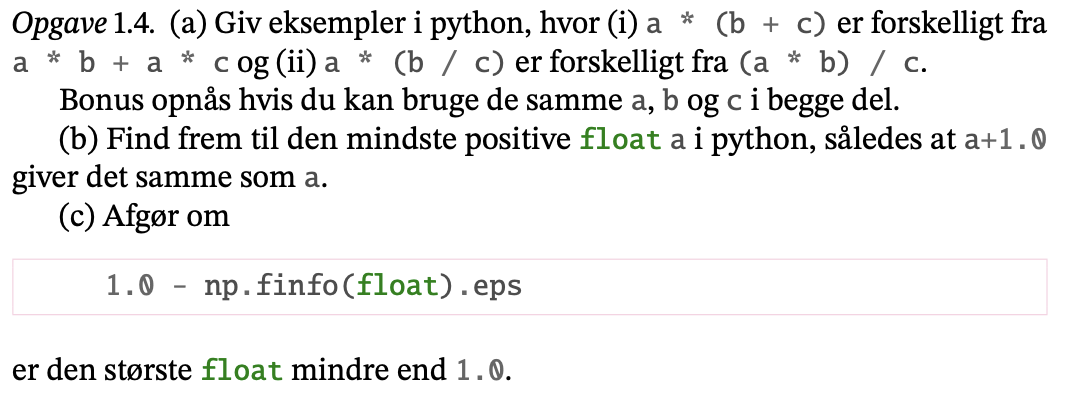

## (a) 

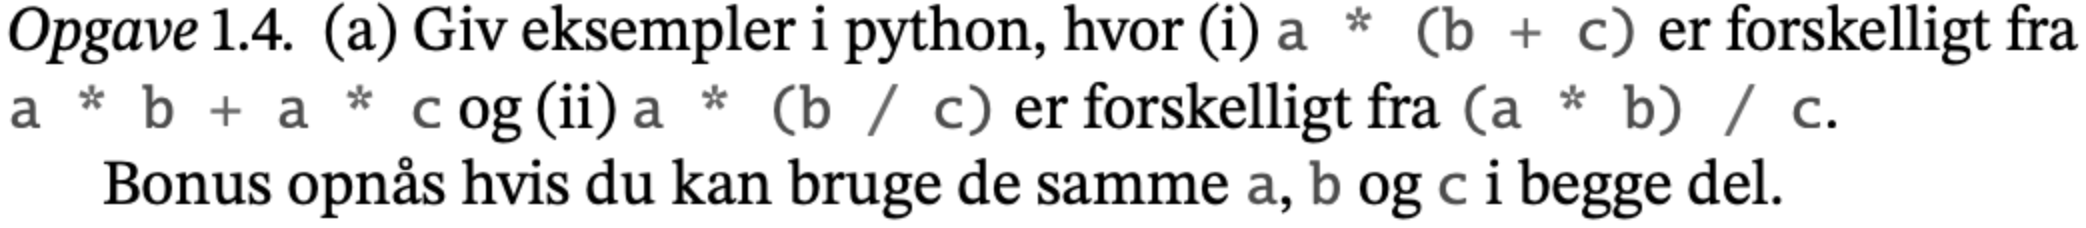

### (i)

In [6]:
a = 6.3
b = 2
c = 7

res1 = a * (b + c)
res2 = a * b + a * c

res1, res2, a * 7

# Den når at regne en skalar af 6.3 ud nok gange til at fejlen ophober sig, og der bliver rundet ned

(56.699999999999996, 56.7, 44.1)

### (ii)

In [7]:
a = 6.3
b = 2
c = 7

res1 = a * (b / c)
res2 = (a * b) / c

res1, res2

(1.7999999999999998, 1.8)

## (b)

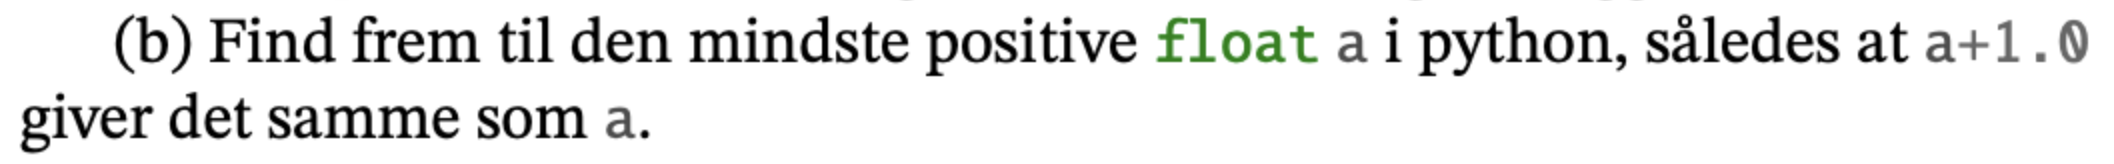

In [8]:
# Svaret må være

a = 2.0**(np.finfo(float).nmant + 1)

b = np.nextafter(a, np.finfo(float).min)

a, a+1.0, b, b+1

(9007199254740992.0,
 9007199254740992.0,
 9007199254740991.0,
 9007199254740992.0)

Vi kan repræsentere et floating point tal ved beregningen:

$$(-1)^{sign} * (1 + M) * 2^{exponent - bias}$$

Normalt er $bias$ lig halvdelen af det tal som exponenten kan repræsentere.

Nedenfor bestemmes antallet af mantisse bits og antallet af exponent bits

In [9]:
np.finfo(float).nmant, np.finfo(float).nexp

(52, 11)

Nedenfor beregnes halvdelen af det som exponent bits kan repræsentere.

In [10]:
bias = 2**10

bias

1024

For ikke at have noget komma tal med mantissen sættes eksponenten til at være $bias + 51$, da dette vil lave alle tallene heltal.

Med $52$ mantisse bits, kan vi max repræsentere $2^{52}$ med en $bias - exponent = 51$. Dermed vil alle tal efter $2^53$ mindst blive 2 større, da eksponenten vokser med 1 efter $2^{53}$.

## (c)

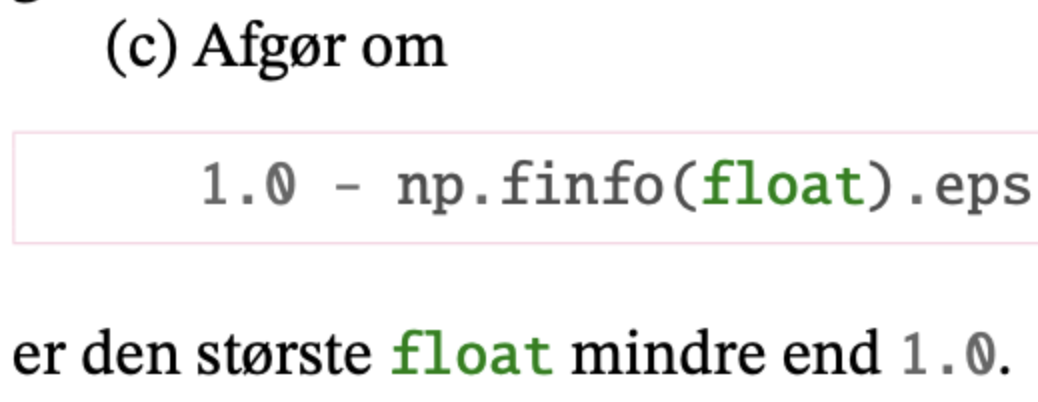

Det er den ikke, dette vises nedenfor:

In [11]:
1.0 - np.finfo(float).eps, np.nextafter(1.0, 0.0)

(0.9999999999999998, 0.9999999999999999)

De to tal ovenfor er tydeligvis ikke de samme.

# Opg 1.5

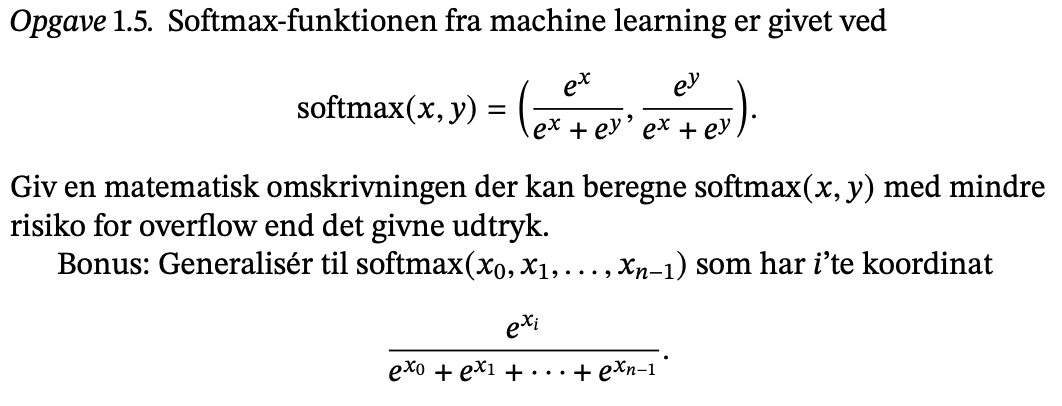

softmax(x, y) kan omskrives således:

$$\text{softmax}(x, y) = (\frac{1}{1+e^{y-x}}, \frac{1}{1+e^{x-y}})$$

# Opg 1.6

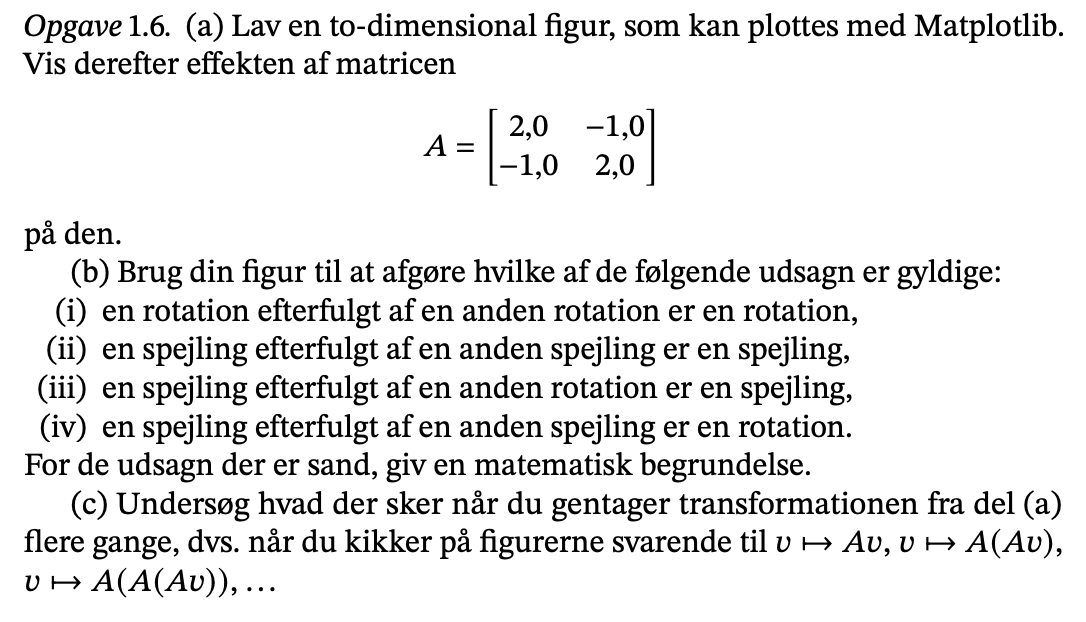

## (a)

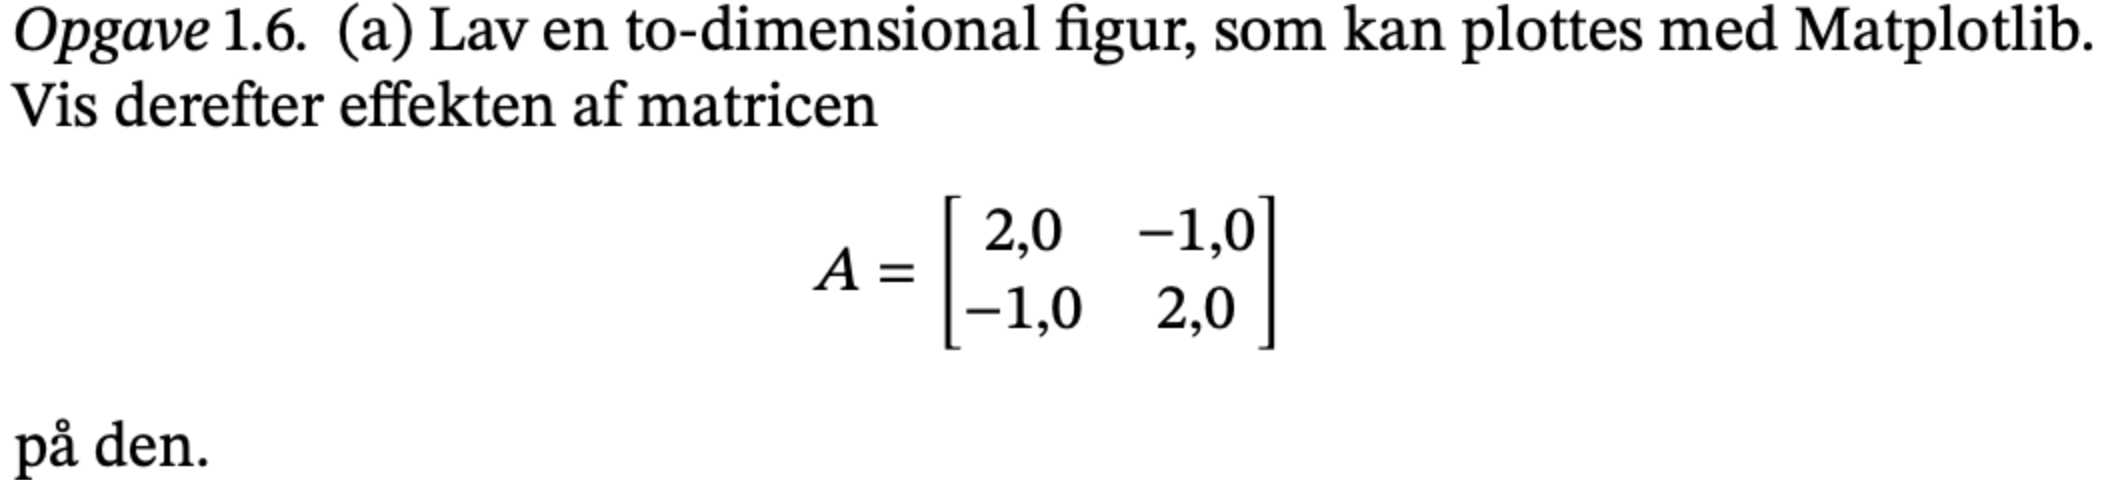

In [12]:
# Angivelse af figur

figur = np.array([[0, 1, 1, 0, 0], 
                  [0, 0, 1, 1, 0]], dtype=float)

A = np.array([[2, -1], 
              [-1, 2]], dtype=float)

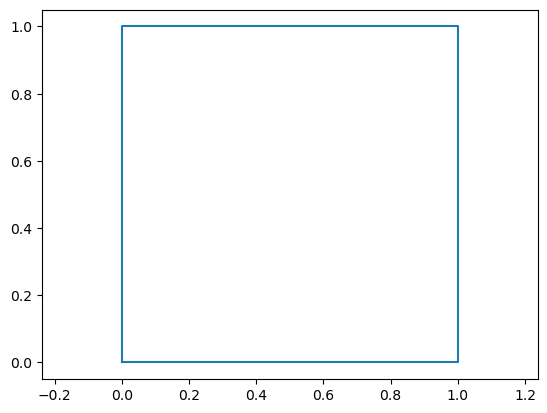

In [25]:
# Plot af figur før matrix produkt

fig, ax = plt.subplots()

ax.axis('equal')

ax.plot(figur[0], figur[1])

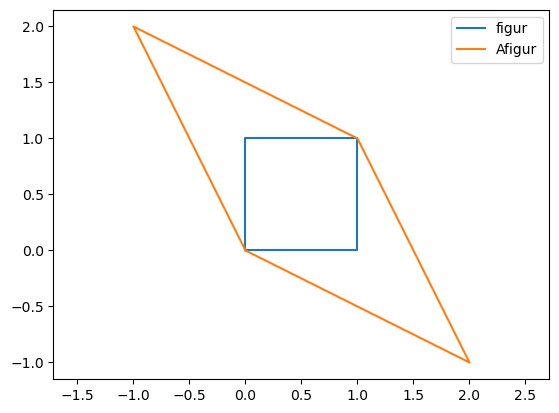

In [14]:
# Plot af figur efter matrix produkt

fig, ax = plt.subplots()

figurnew = A @ figur

ax.axis('equal')

ax.plot(figur[0], figur[1], label="figur")

ax.plot(figurnew[0], figurnew[1], label="Afigur")

ax.legend()

## (b)

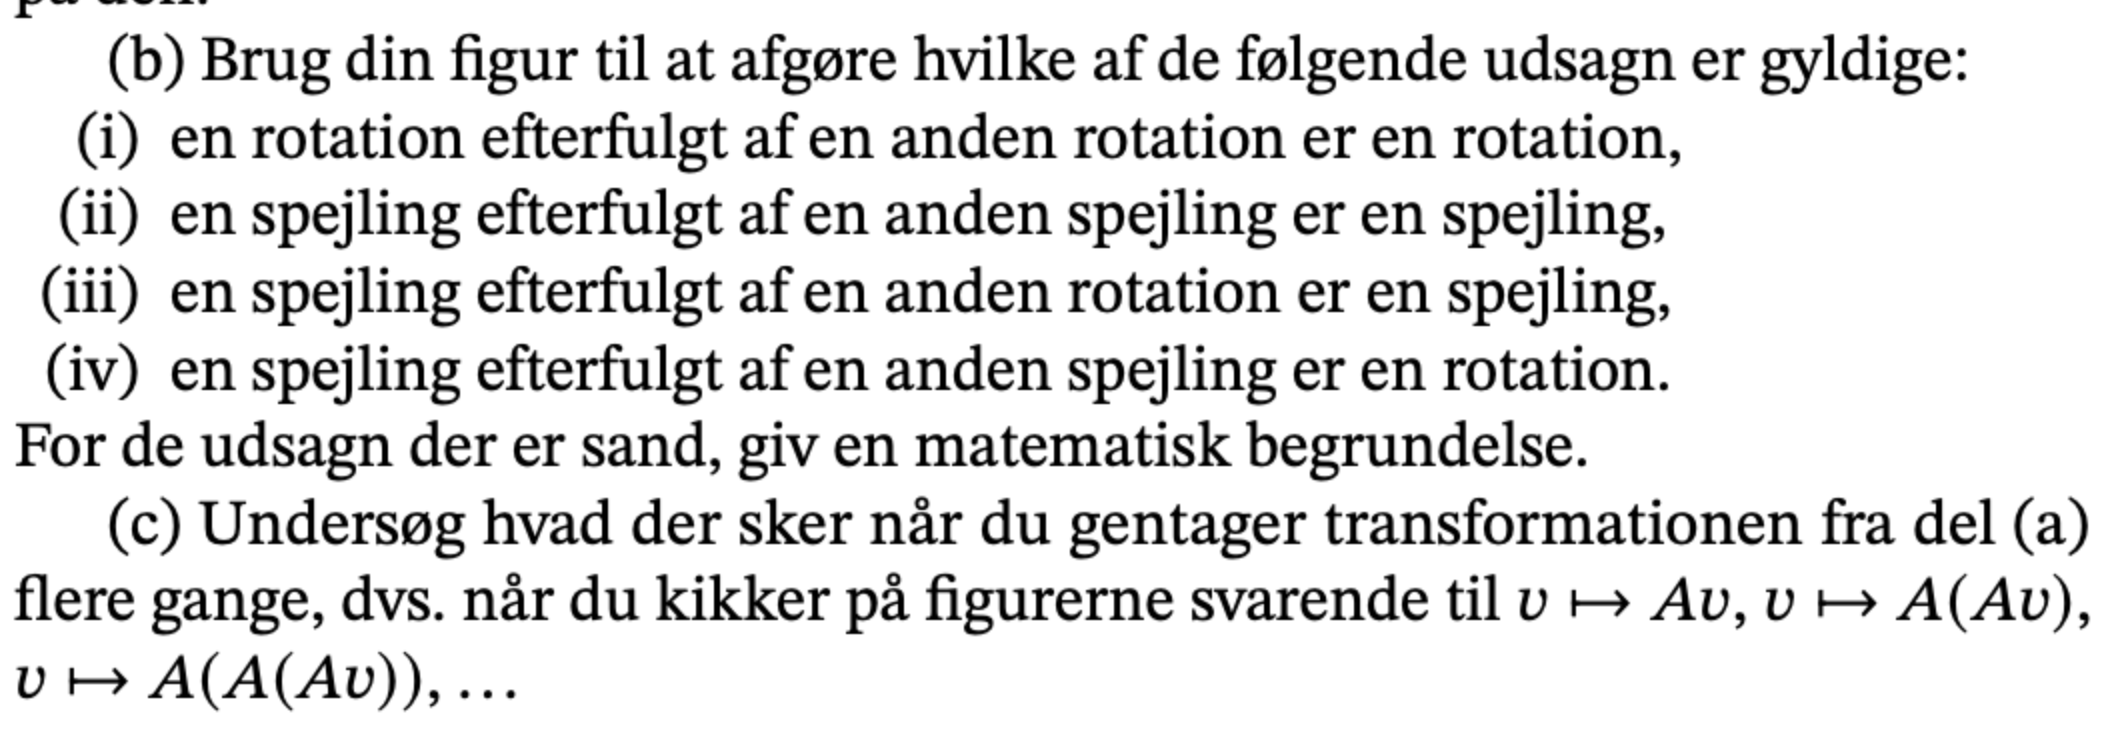

### (i)

Sandt, dette kan ses her:

In [15]:
# Angivelse af figur

figur = np.array([[0, 1, 1, 0, 0], 
                  [0, 0, 1, 1, 0]], dtype=float)

# Angivelse af 1. rotations matrix

cos = np.cos(np.pi/2)
sin = np.sin(np.pi/2)

R1 = [[cos, -sin], 
     [sin, cos]]

# Angivelse af 2. rotations matrix

cos = np.cos(-np.pi/4)
sin = np.sin(-np.pi/4)

R2 = [[cos, -sin], 
     [sin, cos]]

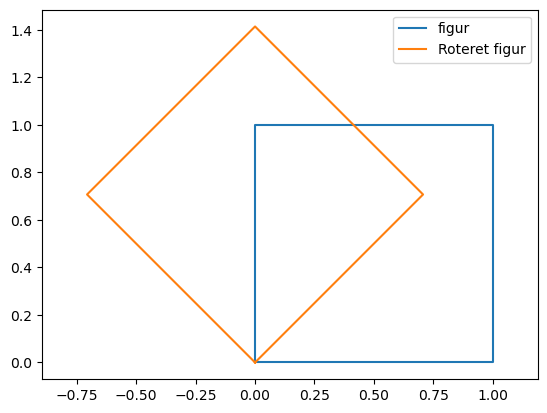

In [16]:
# Plot af figur efter matrix produkt

fig, ax = plt.subplots()

# Roterer figuren 2x

figurnew = R1 @ (R2 @ figur)

ax.axis('equal')

ax.plot(figur[0], figur[1], label="figur")

ax.plot(figurnew[0], figurnew[1], label="Roteret figur")

ax.legend()

Dette er tydeligvis blot en rotation.

Dette vises også matematisk, betragt blot en koordinat:

$$R_2R_1v = \begin{bmatrix} \cos(\theta) & -\sin(\theta) \\ \sin(\theta) & \cos(\theta) \end{bmatrix} 
\begin{bmatrix} \cos(\phi) & -\sin(\phi) \\ \sin(\phi) & \cos(\phi) \end{bmatrix} 
\begin{bmatrix} x \\ y \end{bmatrix}$$

$$R_2R_1v = \begin{bmatrix} \cos(\phi)\cos(\theta) - \sin(\phi)\sin(\theta) & -\sin(\phi)\cos(\theta) - \sin(\theta)\cos(\phi) \\ \sin(\theta)\cos(\phi) + \cos(\theta) \sin(\phi) & -sin(\theta)\sin(\phi) + \cos(\theta)\cos(\phi) \end{bmatrix} 
\begin{bmatrix} x \\ y \end{bmatrix}$$

Dette kan omskrives med sætningerne:
$$\cos(x + y) = \cos(x)\cos(y) - \sin(x)\sin(y)$$
$$\sin(x + y) = \cos(x)\sin(y) + \sin(x)\cos(y)$$

Jeg vil ikke til at gøre dette, men alle indgangene bliver tydeligvis til sinusider og cosinusser, som står på de samme pladser som i en normal rotationsmatrix.

Altså står vi tilbage med en rotationsmatrix, som blot drejer koordinaten en gang.

### (ii)

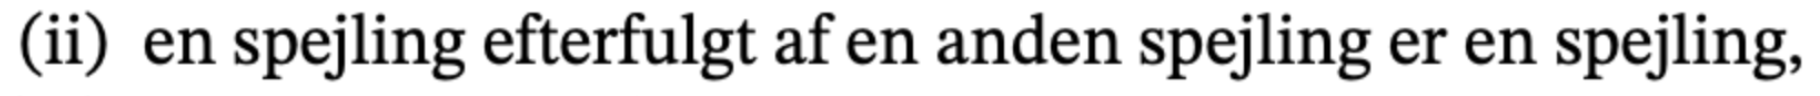

Nej, dette vises nedenfor.

In [17]:
# Angivelse af figur

figur = np.array([[0, 1, 0.5, 0, 0], 
                  [0, 0, 1, 1, 0]], dtype=float)

# Angivelse af 1. spejlings matrix

cos = np.cos(np.pi/2)
sin = np.sin(np.pi/2)

R1 = [[cos, sin], 
     [sin, -cos]]

# Angivelse af 2. spejlings matrix

cos = np.cos(-np.pi/4)
sin = np.sin(-np.pi/4)

R2 = [[cos, sin], 
     [sin, -cos]]

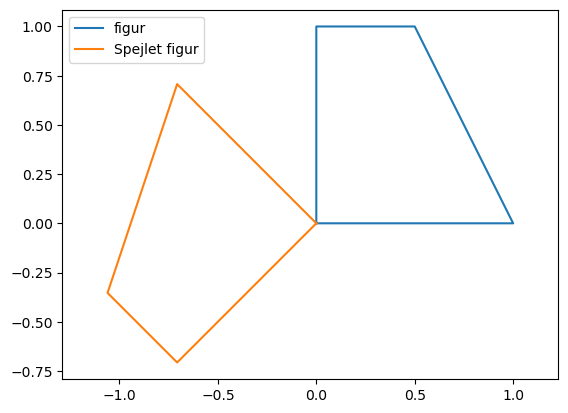

In [18]:
# Plot af figur efter matrix produkt

fig, ax = plt.subplots()

# Roterer figuren 2x

figurnew = R1 @ (R2 @ figur)

ax.axis('equal')

ax.plot(figur[0], figur[1], label="figur")

ax.plot(figurnew[0], figurnew[1], label="Spejlet figur")

ax.legend()

Dette er tydeligvis en rotation og ikke en spejling.

Dette vises også matematisk, betragt blot en koordinat:

$$M_2M_1v = \begin{bmatrix} \cos(\theta) & \sin(\theta) \\ \sin(\theta) & -\cos(\theta) \end{bmatrix} 
\begin{bmatrix} \cos(\phi) & \sin(\phi) \\ \sin(\phi) & -\cos(\phi) \end{bmatrix} 
\begin{bmatrix} x \\ y \end{bmatrix}$$

$$M_2M_1v = \begin{bmatrix} \cos(\phi)\cos(\theta) + \sin(\phi)\sin(\theta) & \sin(\phi)\cos(\theta) - \sin(\theta)\cos(\phi) \\ -\sin(\theta)\cos(\phi) + \cos(\theta) \sin(\phi) & \sin(\theta)\sin(\phi) + \cos(\theta)\cos(\phi) \end{bmatrix} 
\begin{bmatrix} x \\ y \end{bmatrix}$$

Dette kan omskrives med sætningerne:
$$\cos(x + y) = \cos(x)\cos(y) - \sin(x)\sin(y)$$
$$\sin(x + y) = \cos(x)\sin(y) + \sin(x)\cos(y)$$

$$M_2M_1v = \begin{bmatrix} \cos(-\phi)\cos(\theta) - \sin(-\phi)\sin(\theta) & -\sin(-\phi)\cos(\theta) - \sin(\theta)\cos(-\phi) \\ -\sin(\theta)\cos(-\phi) - \cos(\theta) \sin(-\phi) & -\sin(\theta)\sin(-\phi) + \cos(\theta)\cos(-\phi) \end{bmatrix} 
\begin{bmatrix} x \\ y \end{bmatrix}$$

$$M_2M_1v = \begin{bmatrix} \cos(-\phi)\cos(\theta) - \sin(-\phi)\sin(\theta) & -(\sin(-\phi)\cos(\theta) + \sin(\theta)\cos(-\phi)) \\ -(\sin(\theta)\cos(-\phi) + \cos(\theta) \sin(-\phi)) &  \cos(\theta)\cos(-\phi) -\sin(\theta)\sin(-\phi) \end{bmatrix} 
\begin{bmatrix} x \\ y \end{bmatrix}$$

### (iii)

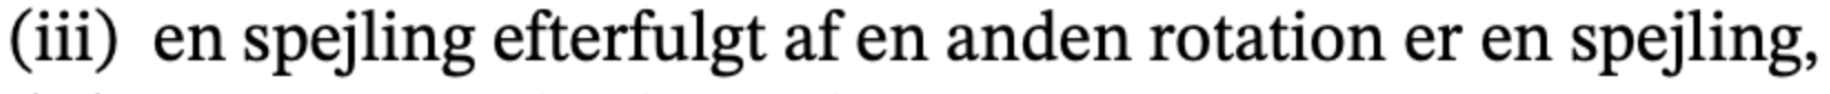

Ja, dette vises nedenfor.

In [19]:
# Angivelse af figur

figur = np.array([[0, 1, 0.5, 0, 0], 
                  [0, 0, 1, 1, 0]], dtype=float)

# Angivelse af 1. spejlings matrix

cos = np.cos(np.pi/2)
sin = np.sin(np.pi/2)

M1 = [[cos, sin], 
     [sin, -cos]]

# Angivelse af 2. rotations matrix

cos = np.cos(-np.pi/4)
sin = np.sin(-np.pi/4)

R2 = [[cos, -sin], 
     [sin, cos]]

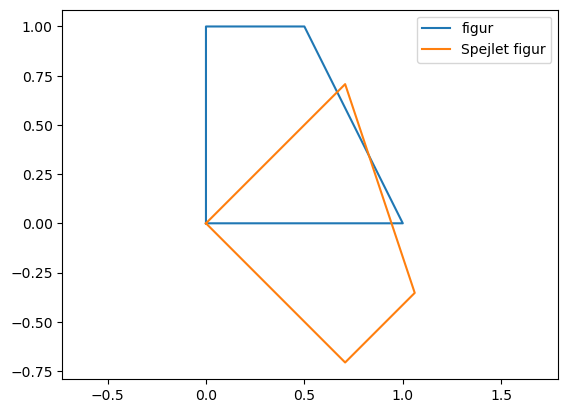

In [20]:
# Plot af figur efter matrix produkt

fig, ax = plt.subplots()

# Roterer figuren 2x

figurnew = R2 @ (M1 @ figur)

ax.axis('equal')

ax.plot(figur[0], figur[1], label="figur")

ax.plot(figurnew[0], figurnew[1], label="Spejlet figur")

ax.legend()

Dette er ret tydeligt ikke en rotation, men en spejling.

### (iiii)

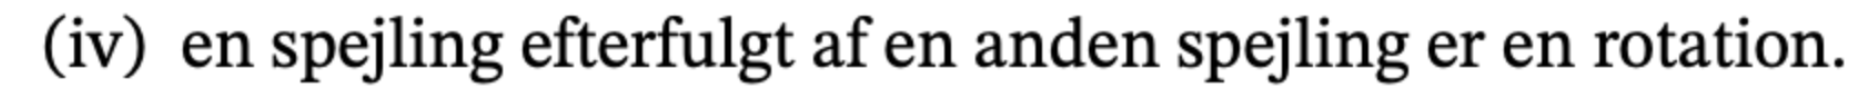

Ja, dette blev vist i (ii)

## (c)

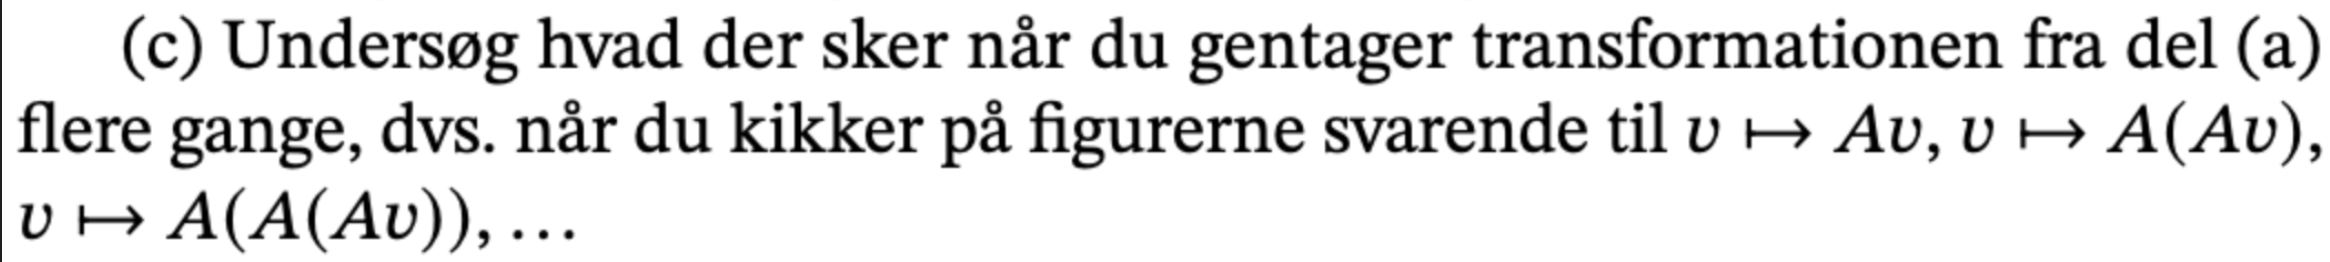

In [21]:
# Angivelse af figur

figur = np.array([[0, 1, 1, 0, 0], 
                  [0, 0, 1, 1, 0]], dtype=float)

A = np.array([[2, -1], 
              [-1, 2]], dtype=float)

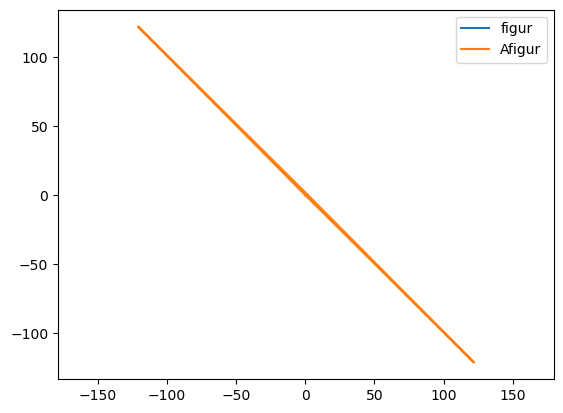

In [22]:
# Plot af figur efter matrix produkt

fig, ax = plt.subplots()

figurnew = A @ A @ A @ A @ A @ figur

ax.axis('equal')

ax.plot(figur[0], figur[1], label="figur")

ax.plot(figurnew[0], figurnew[1], label="Afigur")

ax.legend()

Figuren bliver presset sammen til en streg.